In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import joblib

import load.load_dataset as ds
import load.load_net as nt
import load.nets.training as tr

import torch
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

# **Tuning of hyperparameters to train model**

In [2]:
def plot_roc(y_val, result1, result2, result3, dataset_name):
    y_val_labels = y_val.detach().numpy().argmax(axis=1)

    roc4 = roc_auc_score(y_val_labels, result1['pred_proba'][0][:,1])
    fpr4, tpr4, _ = roc_curve(y_val_labels, result1['pred_proba'][0][:,1])
    
    roc5 = roc_auc_score(y_val_labels, result2['pred_proba'][0][:,1])
    fpr5, tpr5, _ = roc_curve(y_val_labels, result2['pred_proba'][0][:,1])
    
    roc6 = roc_auc_score(y_val_labels, result3['pred_proba'][0][:,1])
    fpr6, tpr6, _ = roc_curve(y_val_labels, result3['pred_proba'][0][:,1])

    plt.figure(figsize=(6,6))
    plt.title(f'{dataset_name} - ROC Curve')
    plt.plot(fpr4, tpr4, color='blue', label=f'ROC smallNN - {roc4:.4f}')
    plt.plot(fpr5, tpr5, color='red', label=f'ROC regNN - {roc5:.4f}')
    plt.plot(fpr6, tpr6, color='green', label=f'ROC CNN1 - {roc6:.4f}')
    plt.plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()


In [3]:
def plot_conf_matrix(y_val, result1, result2, result3):
    cm1 = result1['confusion_matrix'][0]
    cm2 = result2['confusion_matrix'][0]
    cm3 = result3['confusion_matrix'][0]
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
    disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3)
    disp1.plot(cmap=plt.cm.Blues, ax=ax[0])
    disp2.plot(cmap=plt.cm.Blues, ax=ax[1])
    disp3.plot(cmap=plt.cm.Blues, ax=ax[2])
    plt.show()

In [4]:
def eval_net(dataset_name, model_name):
    
    history = joblib.load(f'./models/histories/{dataset_name}_{model_name}_history.joblib')
    axis = np.linspace(0, len(history['train_loss']), len(history['train_loss']))
    fig, ax = plt.subplots(1, 2, figsize = [12,5])
    ax[0].plot(axis, history['train_loss'], label='Train Loss')
    ax[0].plot(axis, history['val_loss'], label='Val Loss')
    ax[0].set_title('Loss')
    ax[0].legend()

    ax[1].plot(axis, history['train_acc'], label='Train Accuracy')
    ax[1].plot(axis, history['val_acc'], label='Val Accuracy')
    ax[1].set_title('Accuracy')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    results = joblib.load(f'./models/results/{dataset_name}_{model_name}_results.joblib')
    print(results['classification_report'][0])
    return results


## **ADULT**

In [5]:
dataset_name = "adult"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(36177, 12) (8045, 12) (1000, 12)


### Adult - smallNN

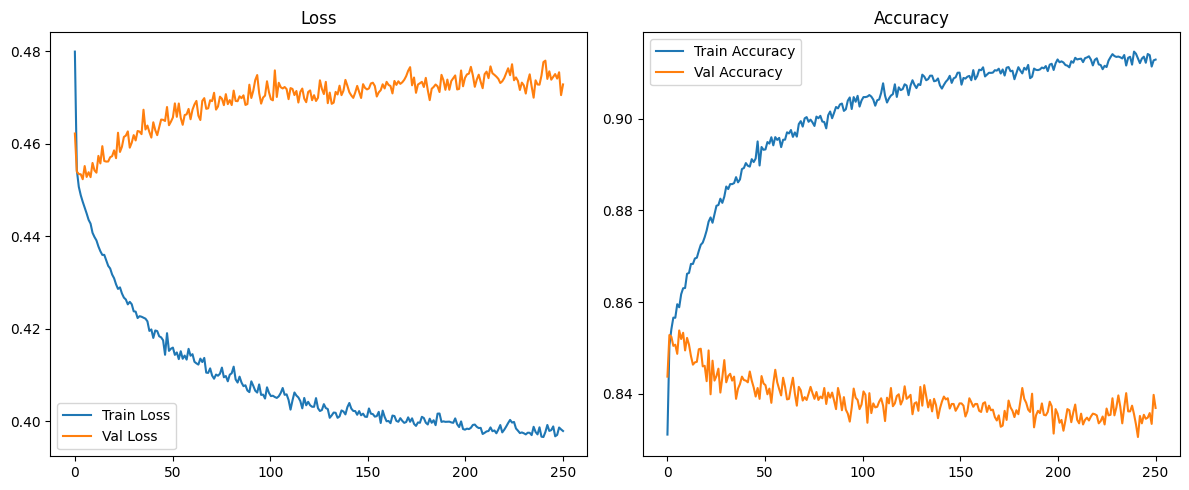

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      6033
           1       0.69      0.63      0.66      2012

    accuracy                           0.84      8045
   macro avg       0.79      0.77      0.78      8045
weighted avg       0.83      0.84      0.83      8045



In [6]:
result1 = eval_net(dataset_name, 'model4')

### Adult - regNN

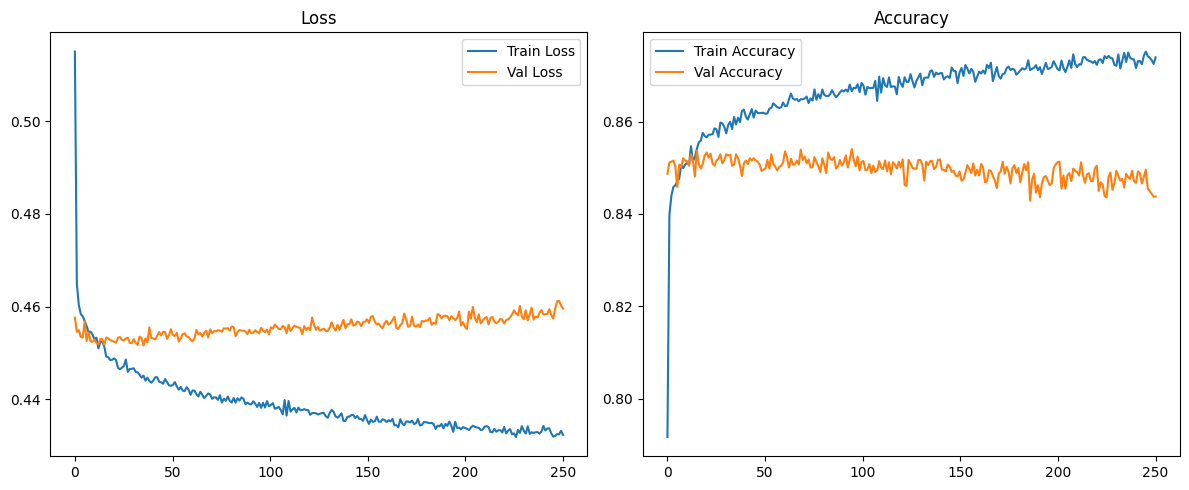

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      6033
           1       0.70      0.66      0.68      2012

    accuracy                           0.84      8045
   macro avg       0.79      0.78      0.79      8045
weighted avg       0.84      0.84      0.84      8045



In [7]:
result2 = eval_net(dataset_name, 'model5')

### Adult - CNN1

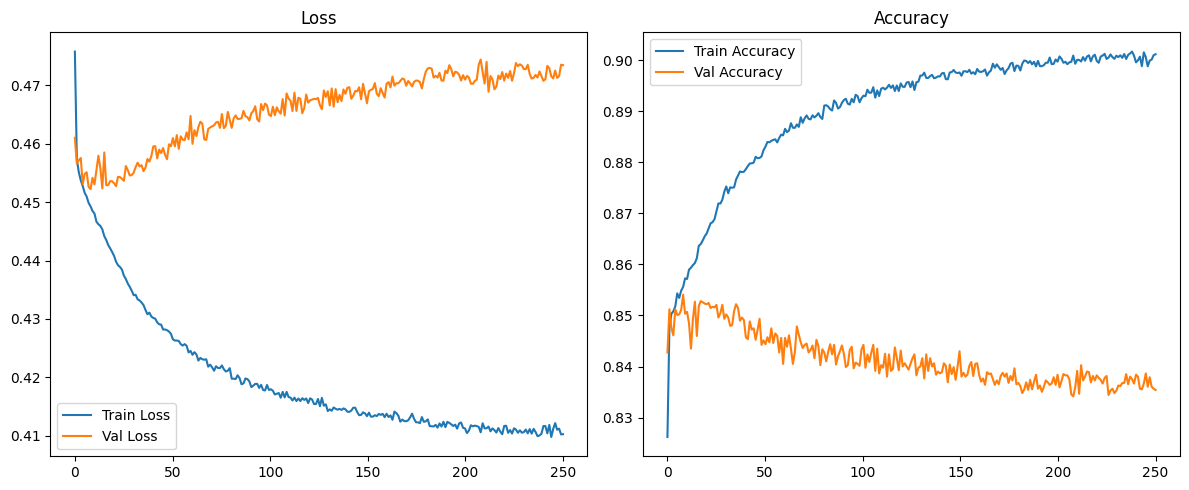

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      6033
           1       0.70      0.60      0.65      2012

    accuracy                           0.84      8045
   macro avg       0.79      0.76      0.77      8045
weighted avg       0.83      0.84      0.83      8045



In [8]:
result3 = eval_net(dataset_name, 'model6')

### Adult - ROC AUC Confusion Matrix

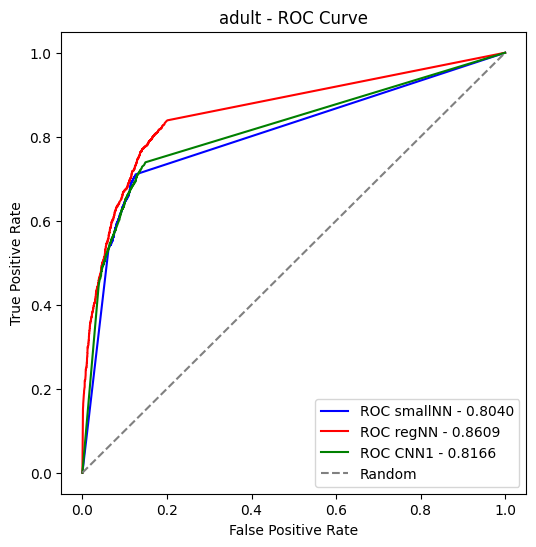

In [9]:
plot_roc(y_val, result1, result2, result3, dataset_name)

In [10]:
#plot_conf_matrix(y_val, result1, result2, result3)

## **BANK**

In [11]:
dataset_name = "bank"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(36168, 14) (8043, 14) (1000, 14)


### Bank - smallNN

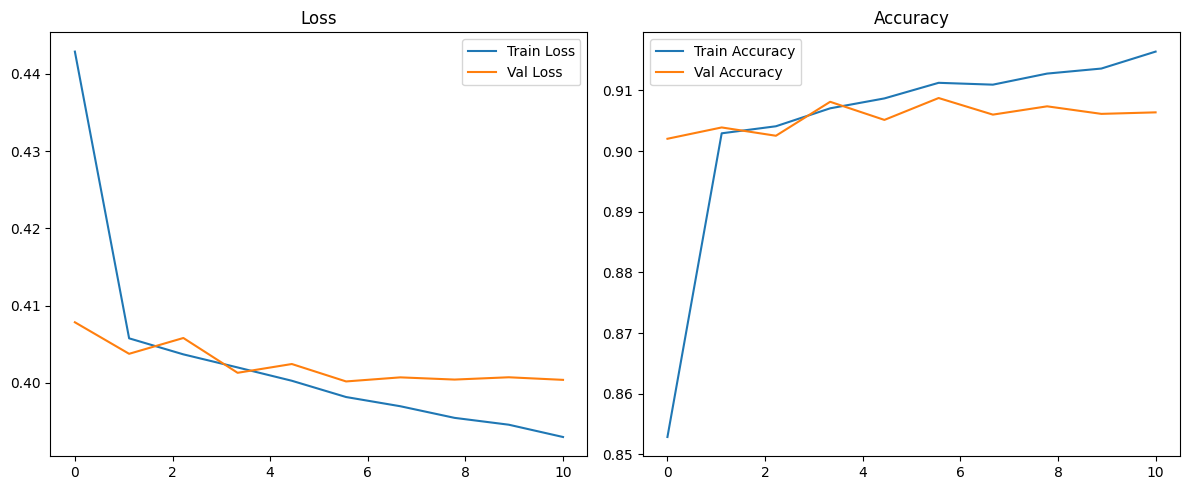

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7098
           1       0.62      0.51      0.56       945

    accuracy                           0.91      8043
   macro avg       0.78      0.73      0.75      8043
weighted avg       0.90      0.91      0.90      8043



In [12]:
result1 = eval_net(dataset_name, 'model4')

### Bank - regNN

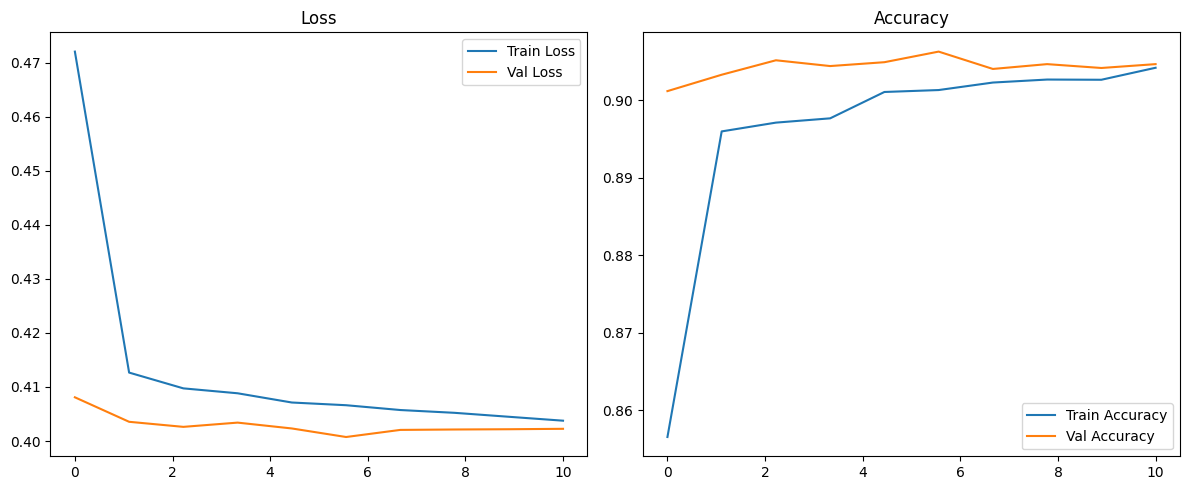

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7098
           1       0.65      0.41      0.50       945

    accuracy                           0.90      8043
   macro avg       0.79      0.69      0.72      8043
weighted avg       0.89      0.90      0.89      8043



In [13]:
result2 = eval_net(dataset_name, 'model5')

### Bank - CNN1

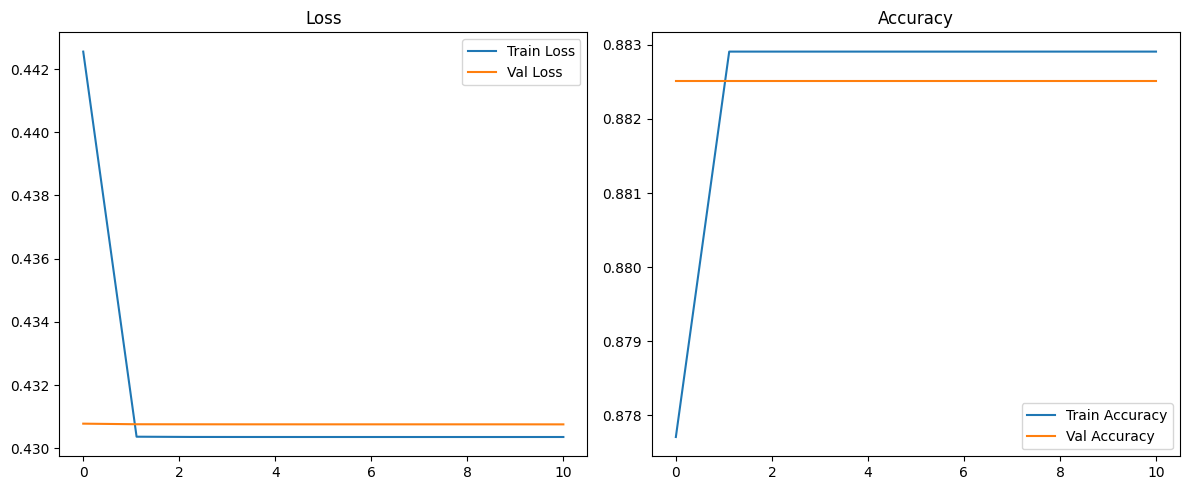

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7098
           1       0.00      0.00      0.00       945

    accuracy                           0.88      8043
   macro avg       0.44      0.50      0.47      8043
weighted avg       0.78      0.88      0.83      8043



In [14]:
result3 = eval_net(dataset_name, 'model6')

### Bank - ROC AUC Confusion Matrix

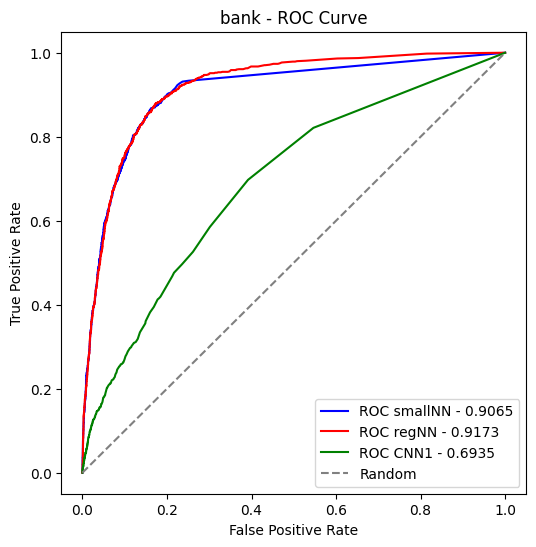

In [15]:
plot_roc(y_val, result1, result2, result3, dataset_name)

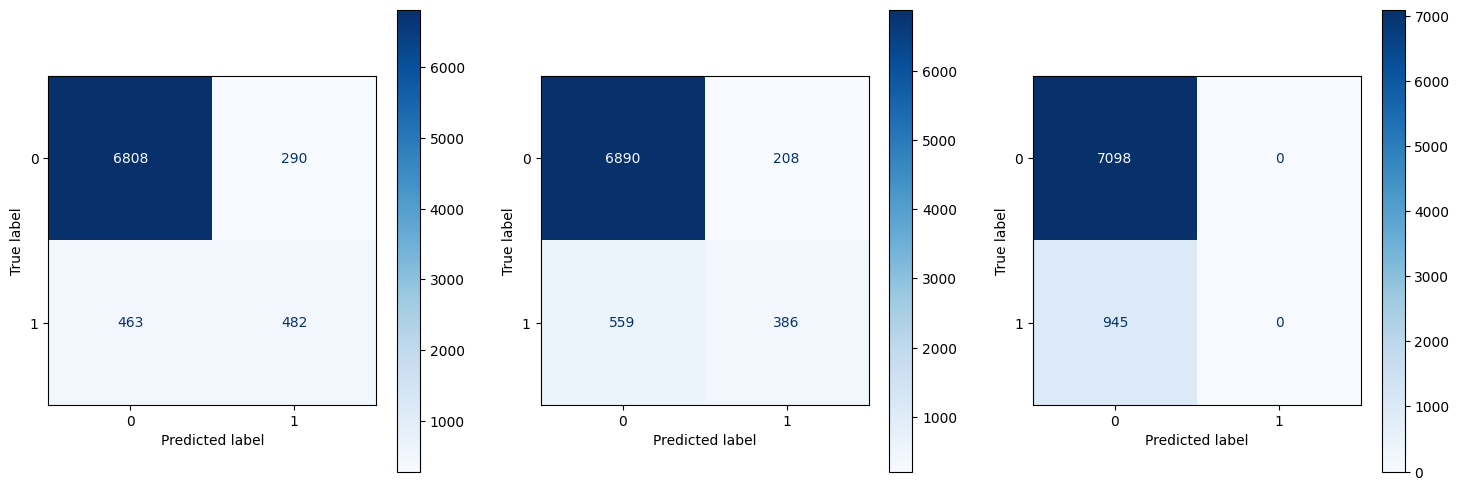

In [16]:
plot_conf_matrix(y_val, result1, result2, result3)

## **BEANS**

In [54]:
dataset_name = "beans"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(10888, 7) (2223, 7) (500, 7)


### Beans - smallNN

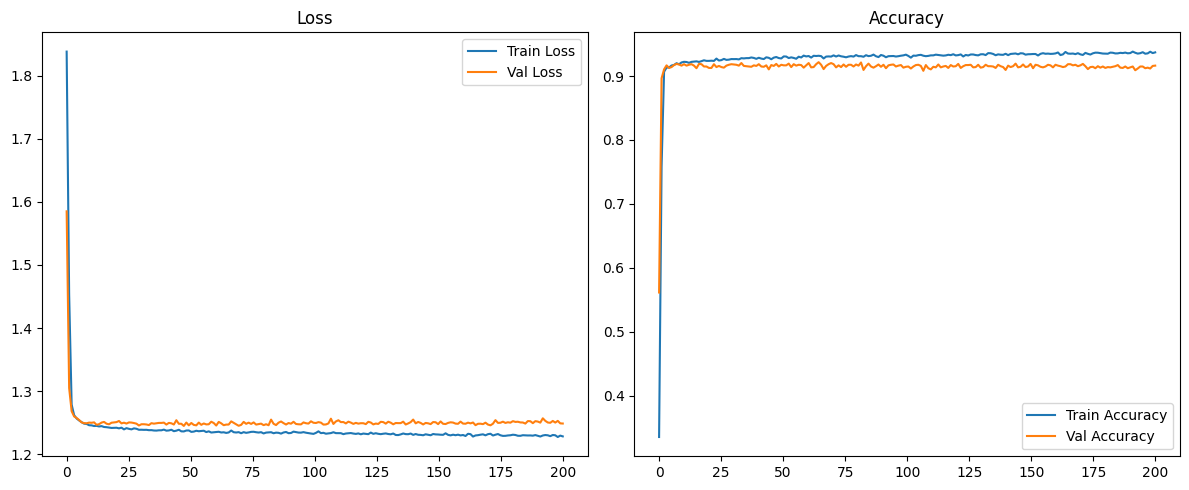

              precision    recall  f1-score   support

           0       0.92      0.87      0.90       212
           1       1.00      0.99      0.99        71
           2       0.91      0.94      0.93       263
           3       0.90      0.93      0.91       589
           4       0.99      0.95      0.97       314
           5       0.92      0.95      0.94       330
           6       0.87      0.85      0.86       444

    accuracy                           0.92      2223
   macro avg       0.93      0.92      0.93      2223
weighted avg       0.92      0.92      0.92      2223



In [55]:
result1 = eval_net(dataset_name, 'model4')

### Beans - regNN

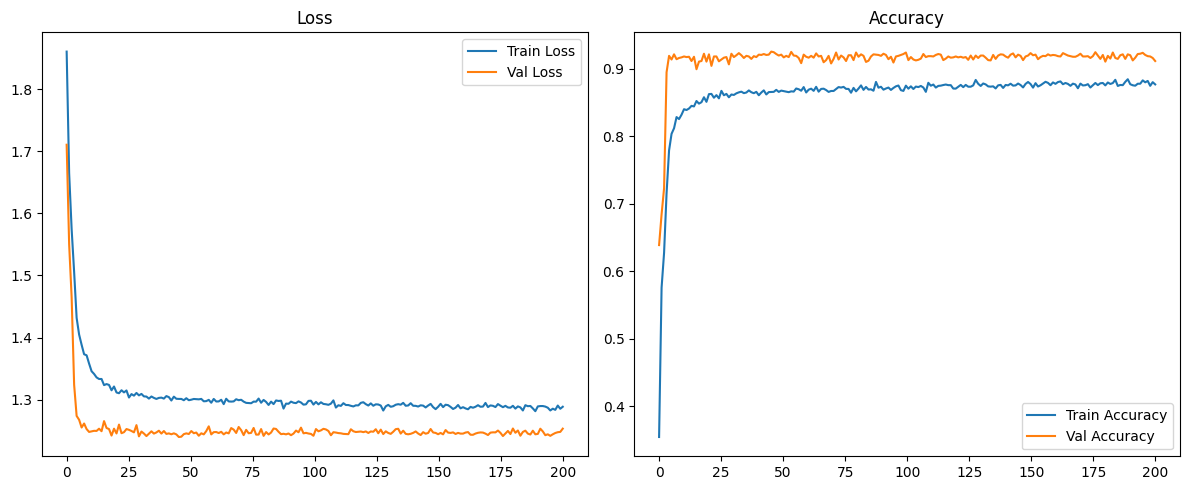

              precision    recall  f1-score   support

           0       0.85      0.90      0.88       212
           1       1.00      0.97      0.99        71
           2       0.91      0.89      0.90       263
           3       0.93      0.89      0.91       589
           4       0.98      0.95      0.96       314
           5       0.93      0.95      0.94       330
           6       0.84      0.89      0.86       444

    accuracy                           0.91      2223
   macro avg       0.92      0.92      0.92      2223
weighted avg       0.91      0.91      0.91      2223



In [56]:
result2 = eval_net(dataset_name, 'model5')

### Beans - CNN1

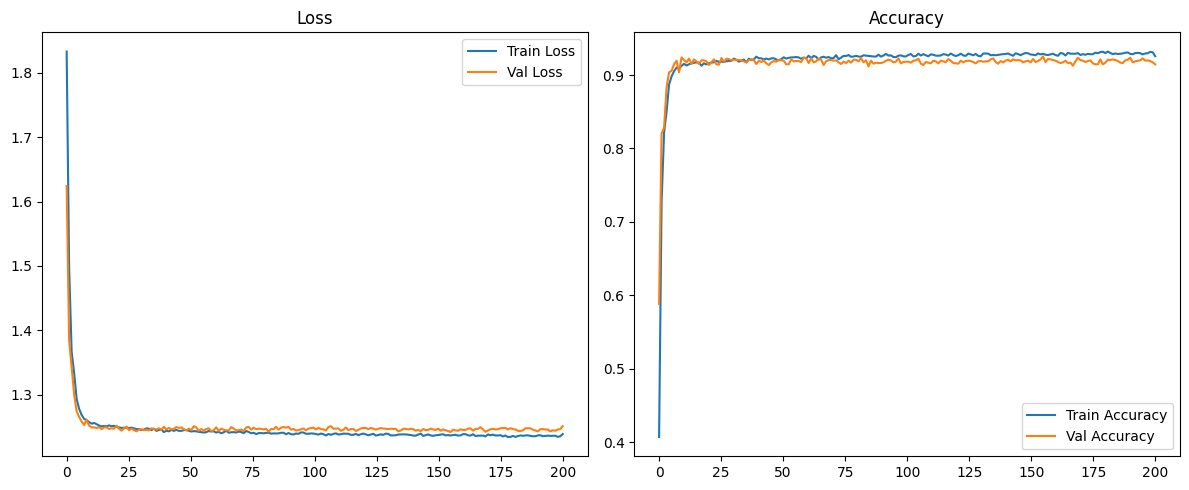

              precision    recall  f1-score   support

           0       0.94      0.90      0.92       212
           1       1.00      1.00      1.00        71
           2       0.91      0.95      0.93       263
           3       0.94      0.86      0.90       589
           4       0.97      0.95      0.96       314
           5       0.93      0.95      0.94       330
           6       0.82      0.90      0.86       444

    accuracy                           0.91      2223
   macro avg       0.93      0.93      0.93      2223
weighted avg       0.92      0.91      0.91      2223



In [57]:
result3 = eval_net(dataset_name, 'model6')

### Beans - ROC AUC Confusion Matrix

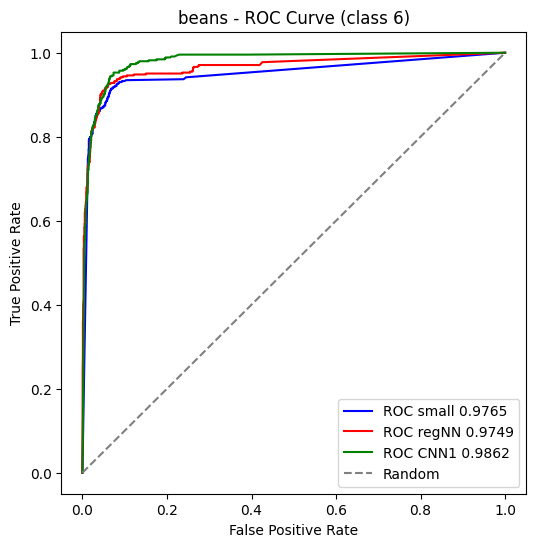

In [65]:
y_val_labels = y_val.detach().numpy().argmax(axis=1)

roc4 = roc_auc_score(y_val_labels, result1['pred_proba'][0], multi_class='ovr')
roc5 = roc_auc_score(y_val_labels, result2['pred_proba'][0], multi_class='ovr')
roc6 = roc_auc_score(y_val_labels, result3['pred_proba'][0], multi_class='ovr')

class_idx = 6 # roc curve for each class

fpr4, tpr4, _ = roc_curve(y_val_labels == class_idx, result1['pred_proba'][0][:, class_idx])
fpr5, tpr5, _ = roc_curve(y_val_labels == class_idx, result2['pred_proba'][0][:, class_idx])
fpr6, tpr6, _ = roc_curve(y_val_labels == class_idx, result3['pred_proba'][0][:, class_idx])

plt.figure(figsize=(6,6))
plt.title(f'{dataset_name} - ROC Curve (class {class_idx})')
plt.plot(fpr4, tpr4, color='blue', label=f'ROC small {roc4:.4f}')
plt.plot(fpr5, tpr5, color='red', label=f'ROC regNN {roc5:.4f}')
plt.plot(fpr6, tpr6, color='green', label=f'ROC CNN1 {roc6:.4f}')
plt.plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

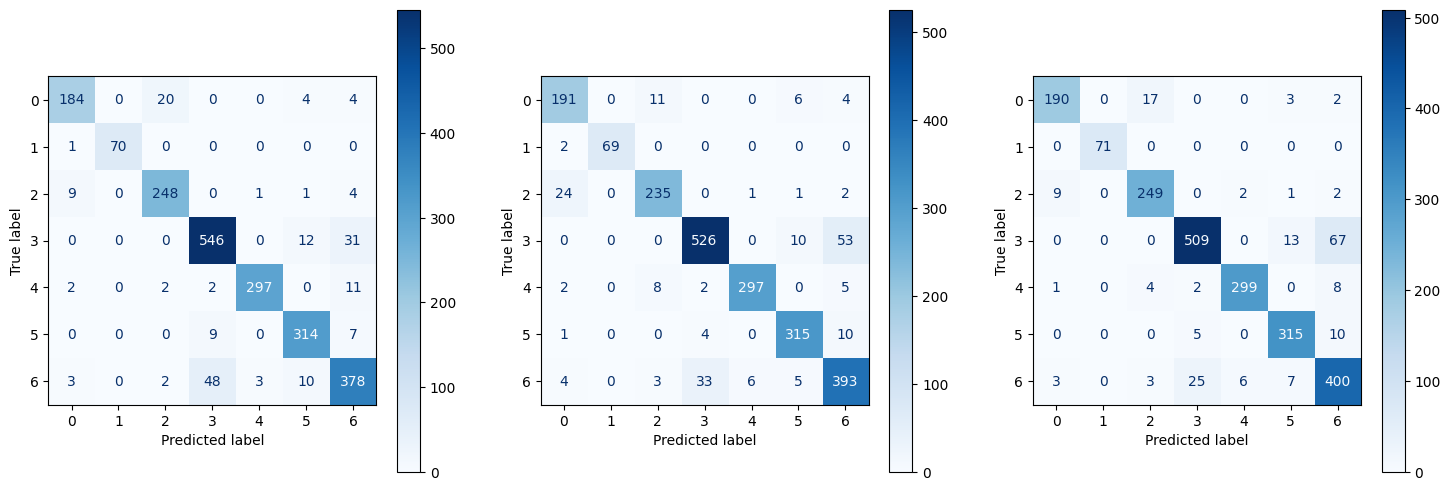

In [59]:
plot_conf_matrix(y_val, result1, result2, result3)

## **CANCER**

In [23]:
dataset_name = "cancer"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(397, 15) (121, 15) (50, 15)


### Cancer - smallNN

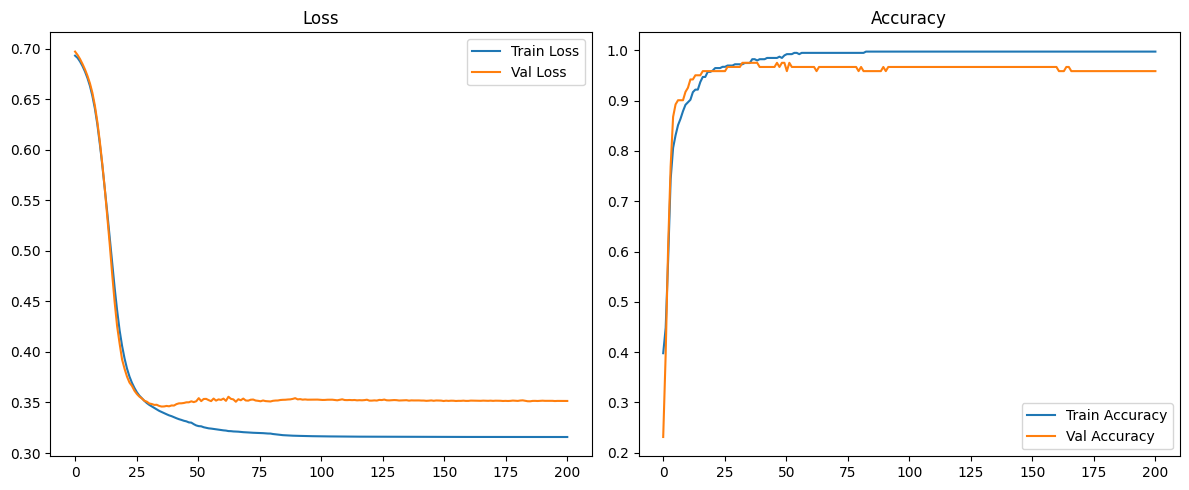

              precision    recall  f1-score   support

           0       0.99      0.96      0.97        91
           1       0.88      0.97      0.92        30

    accuracy                           0.96       121
   macro avg       0.93      0.96      0.95       121
weighted avg       0.96      0.96      0.96       121



In [24]:
result1 = eval_net(dataset_name, 'model4')

### Cancer - regNN

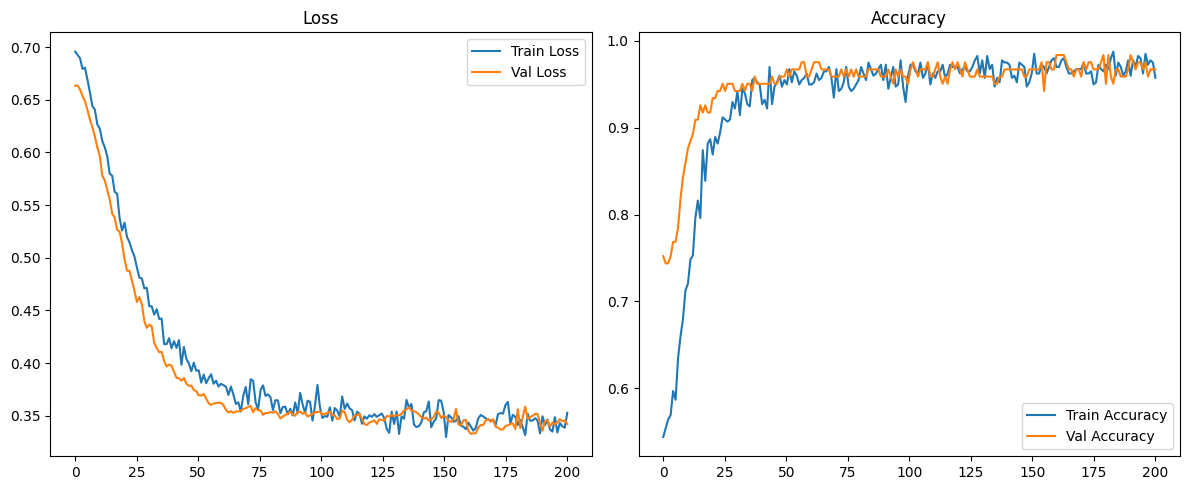

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        91
           1       0.93      0.93      0.93        30

    accuracy                           0.97       121
   macro avg       0.96      0.96      0.96       121
weighted avg       0.97      0.97      0.97       121



In [25]:
result2 = eval_net(dataset_name, 'model5')

### Cancer - CNN1

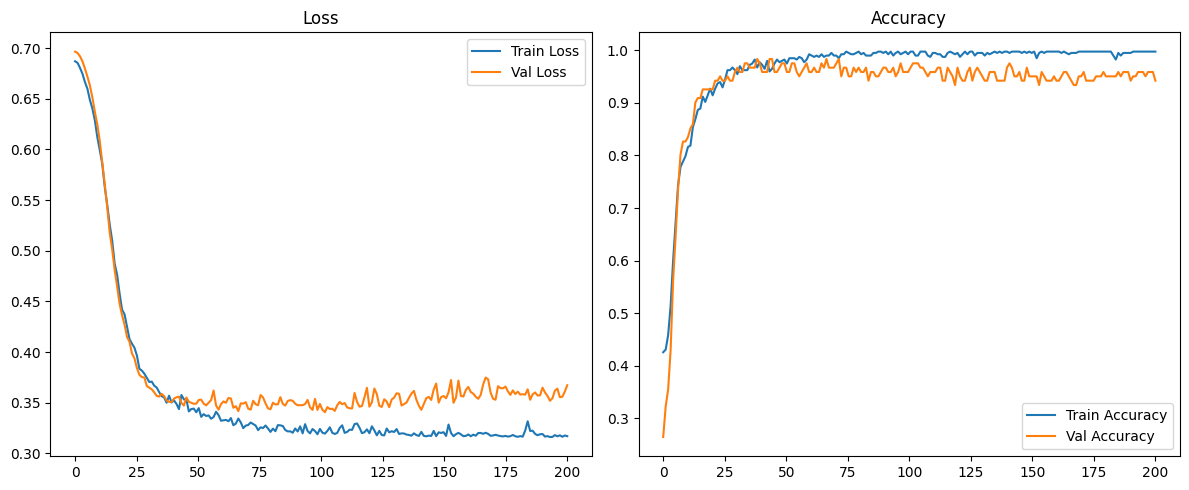

              precision    recall  f1-score   support

           0       0.99      0.93      0.96        91
           1       0.83      0.97      0.89        30

    accuracy                           0.94       121
   macro avg       0.91      0.95      0.93       121
weighted avg       0.95      0.94      0.94       121



In [26]:
result3 = eval_net(dataset_name, 'model6')

### Cancer - ROC AUC Confusion Martix

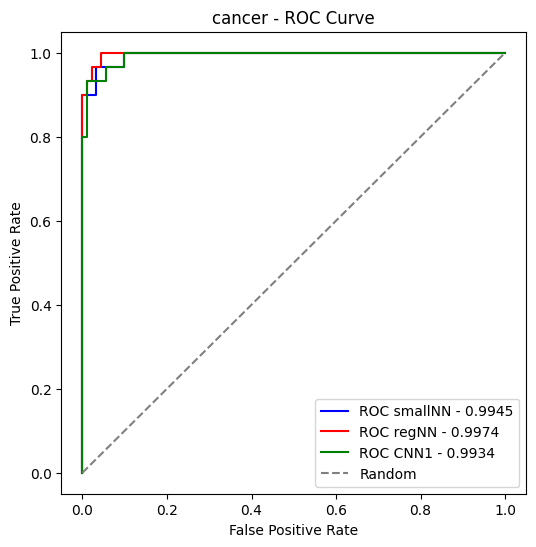

In [27]:
plot_roc(y_val, result1, result2, result3, dataset_name)

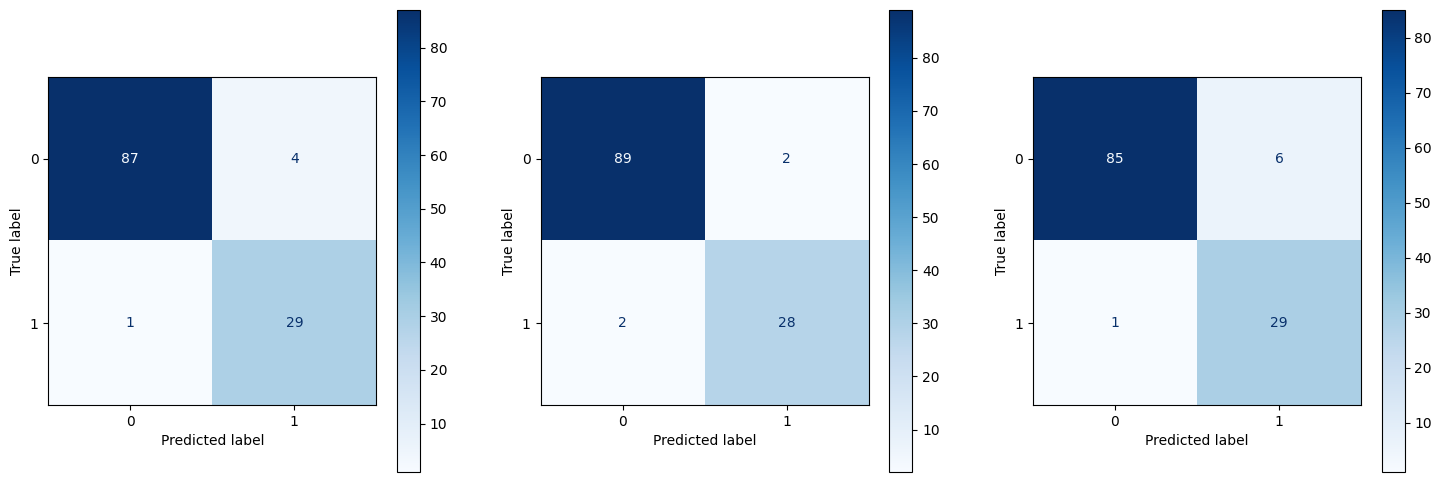

In [28]:
plot_conf_matrix(y_val, result1, result2, result3)

## **HELOC**

In [29]:
dataset_name = "heloc"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(8367, 16) (1592, 16) (500, 16)


### Heloc - smallNN

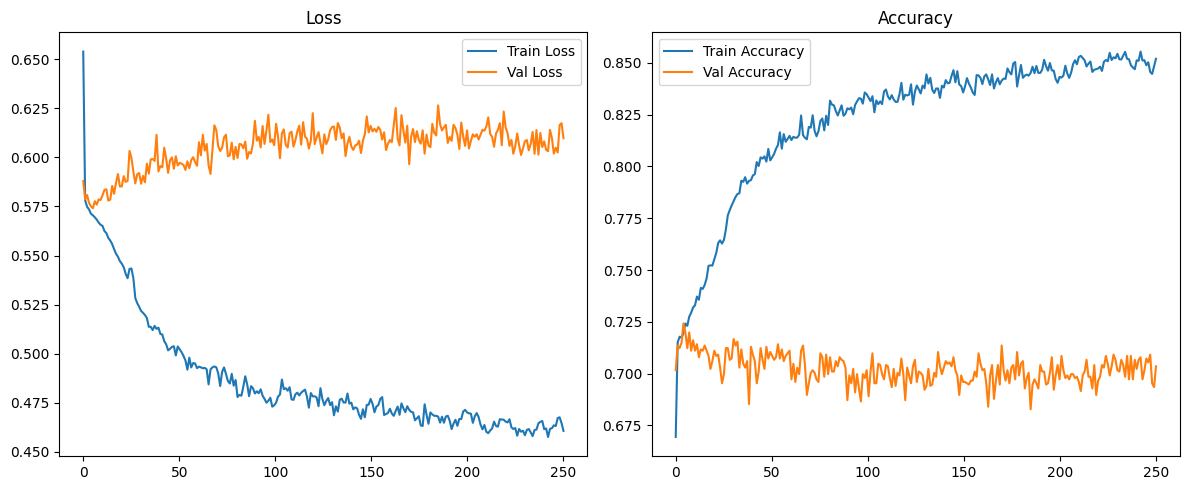

              precision    recall  f1-score   support

           0       0.72      0.73      0.72       846
           1       0.69      0.67      0.68       746

    accuracy                           0.70      1592
   macro avg       0.70      0.70      0.70      1592
weighted avg       0.70      0.70      0.70      1592



In [30]:
result1 = eval_net(dataset_name, 'model4')

### Heloc - regNN

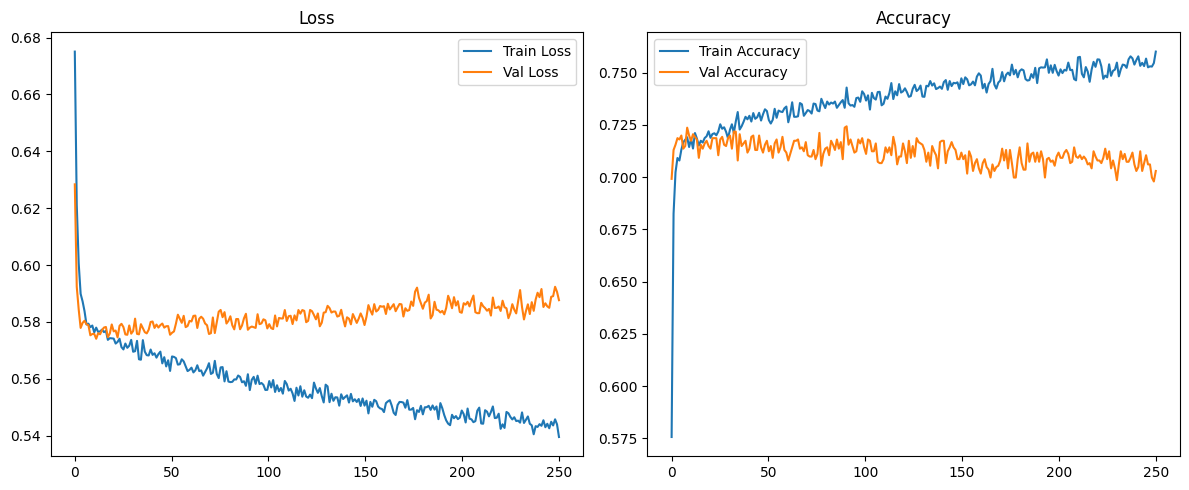

              precision    recall  f1-score   support

           0       0.71      0.74      0.73       846
           1       0.69      0.66      0.68       746

    accuracy                           0.70      1592
   macro avg       0.70      0.70      0.70      1592
weighted avg       0.70      0.70      0.70      1592



In [31]:
result2 = eval_net(dataset_name, 'model5')

### Heloc - CNN1

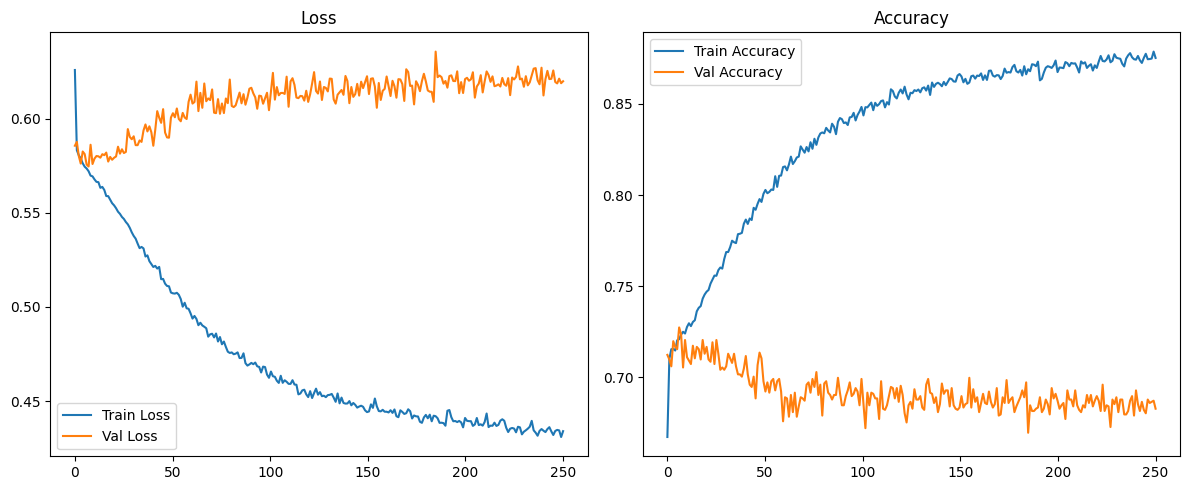

              precision    recall  f1-score   support

           0       0.70      0.70      0.70       846
           1       0.66      0.67      0.66       746

    accuracy                           0.68      1592
   macro avg       0.68      0.68      0.68      1592
weighted avg       0.68      0.68      0.68      1592



In [32]:
result3 = eval_net(dataset_name, 'model6')

### Heloc - ROC AUC Confusion Matrix

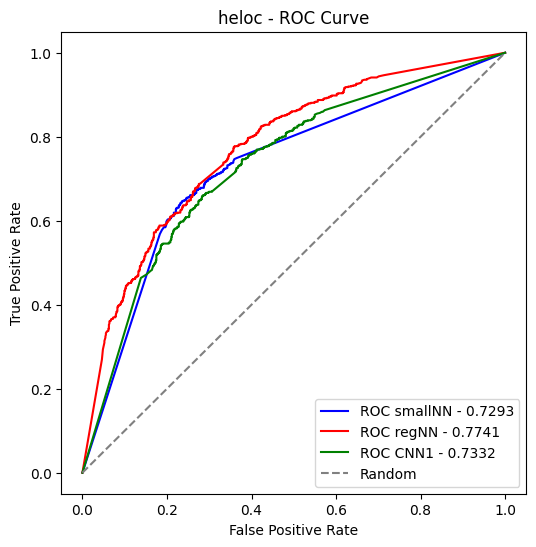

In [33]:
plot_roc(y_val, result1, result2, result3, dataset_name)

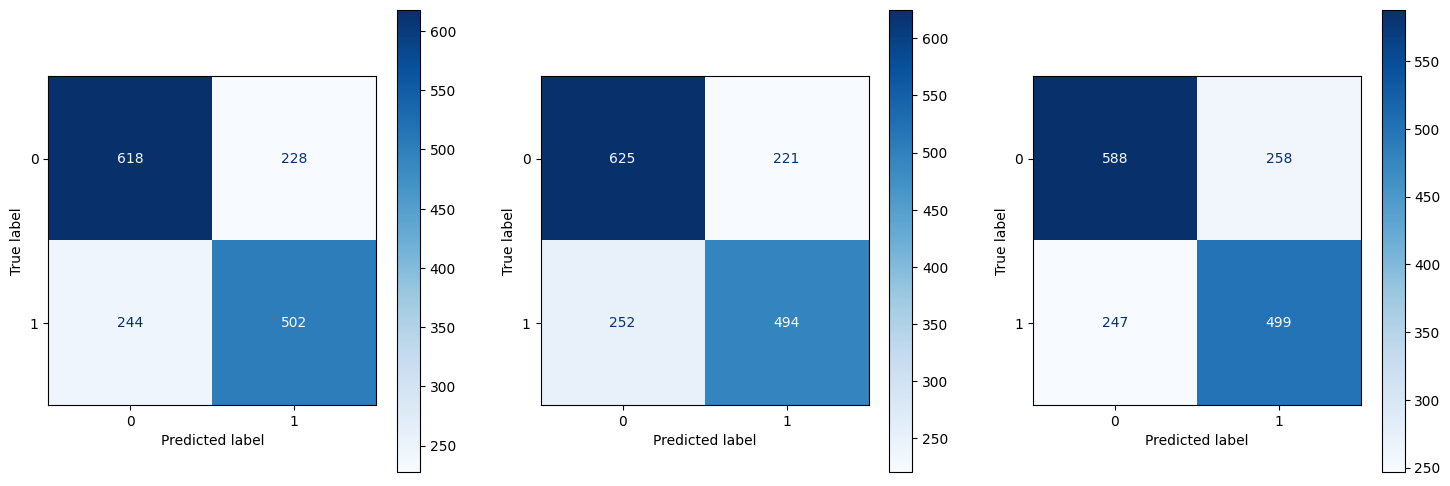

In [34]:
plot_conf_matrix(y_val, result1, result2, result3)

## **MUSHROOM**

In [35]:
dataset_name = "mushroom"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(6498, 21) (1225, 21) (400, 21)


### Mushroom - smallNN

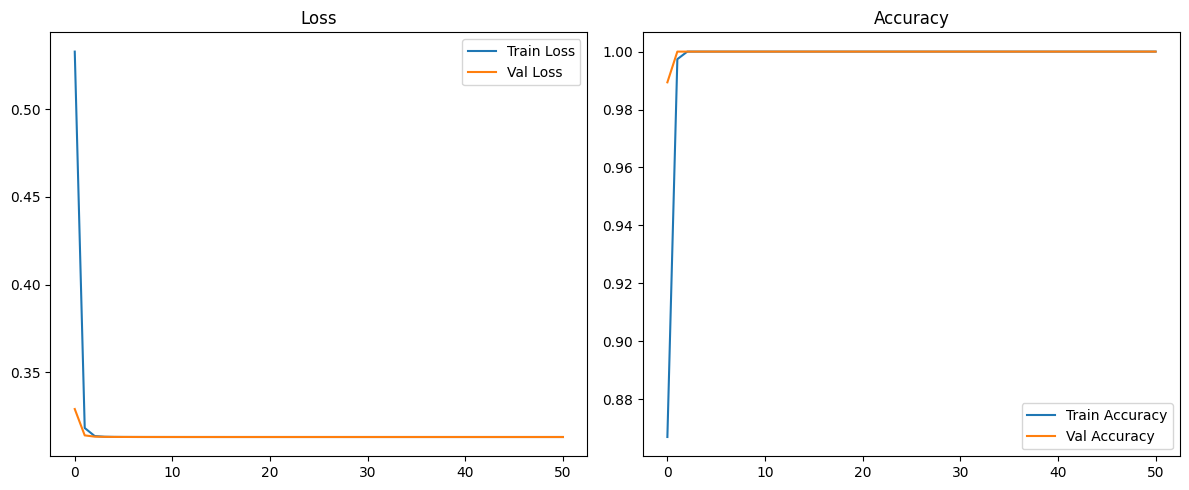

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       613
           1       1.00      1.00      1.00       612

    accuracy                           1.00      1225
   macro avg       1.00      1.00      1.00      1225
weighted avg       1.00      1.00      1.00      1225



In [36]:
result1 = eval_net(dataset_name, 'model4')

### Mushroom - regNN

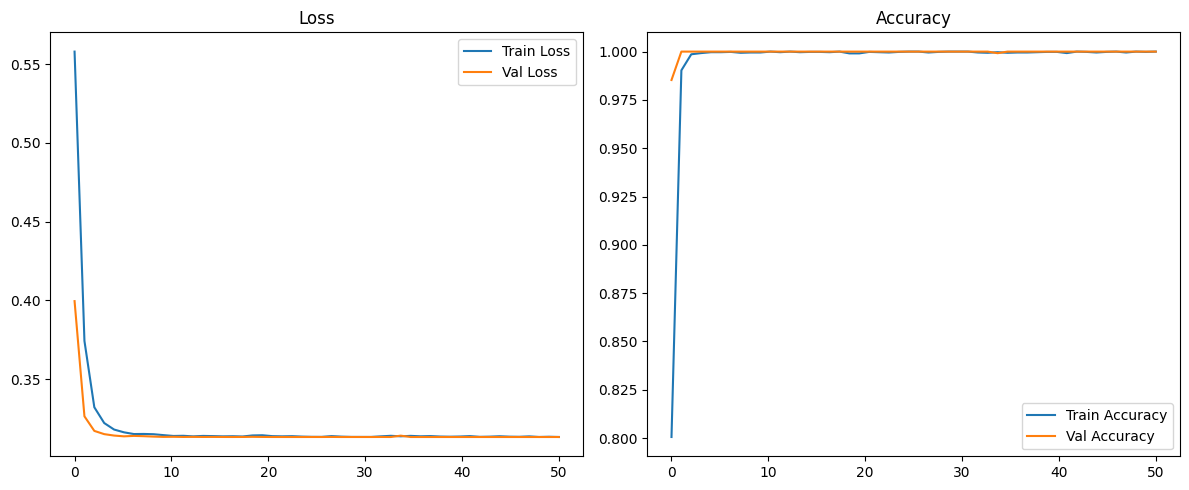

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       613
           1       1.00      1.00      1.00       612

    accuracy                           1.00      1225
   macro avg       1.00      1.00      1.00      1225
weighted avg       1.00      1.00      1.00      1225



In [37]:
result2 = eval_net(dataset_name, 'model5')

### Mushroom - CNN1

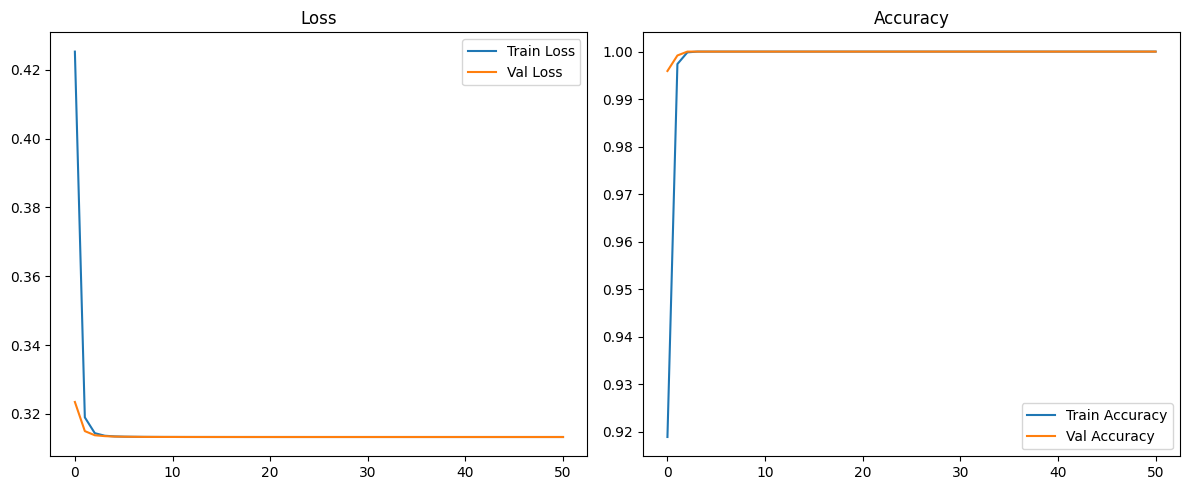

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       613
           1       1.00      1.00      1.00       612

    accuracy                           1.00      1225
   macro avg       1.00      1.00      1.00      1225
weighted avg       1.00      1.00      1.00      1225



In [38]:
result3 = eval_net(dataset_name, 'model6')

### Mushroom - ROC AUC Confusion Matrix

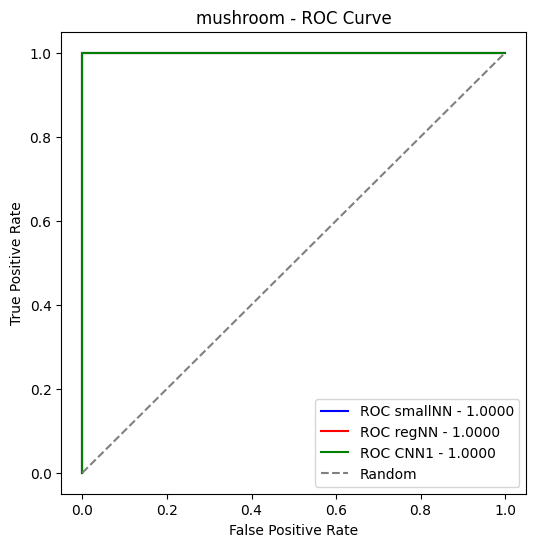

In [39]:
plot_roc(y_val, result1, result2, result3, dataset_name)

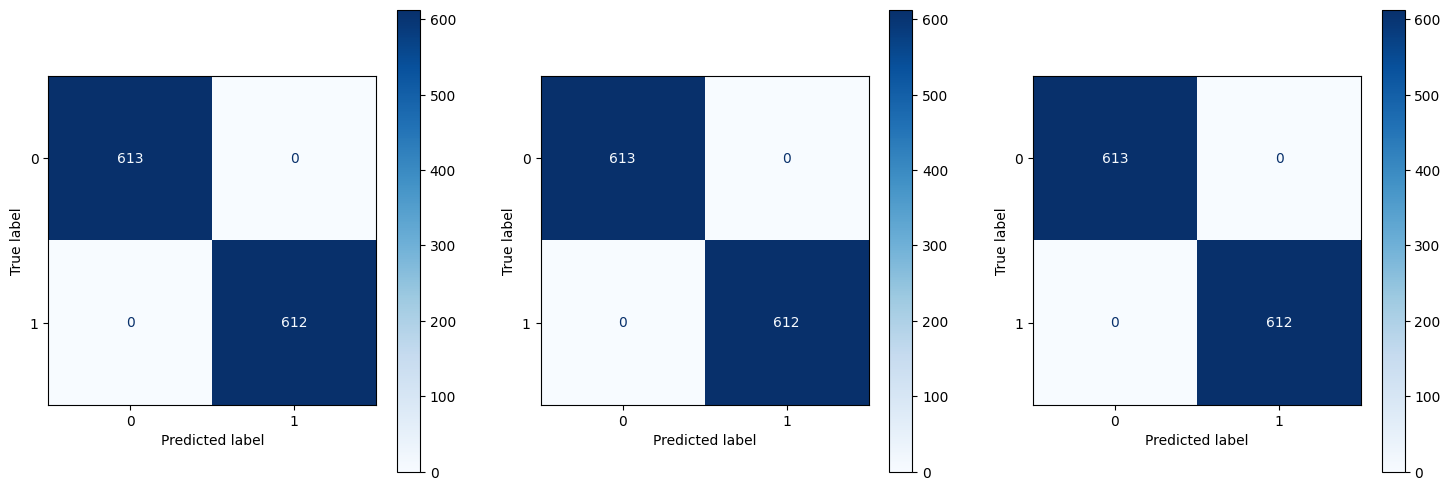

In [40]:
plot_conf_matrix(y_val, result1, result2, result3)

## **OCEAN**

In [66]:
dataset_name = "ocean"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(109259, 8) (30328, 8) (10000, 8)


### Ocean - smallNN

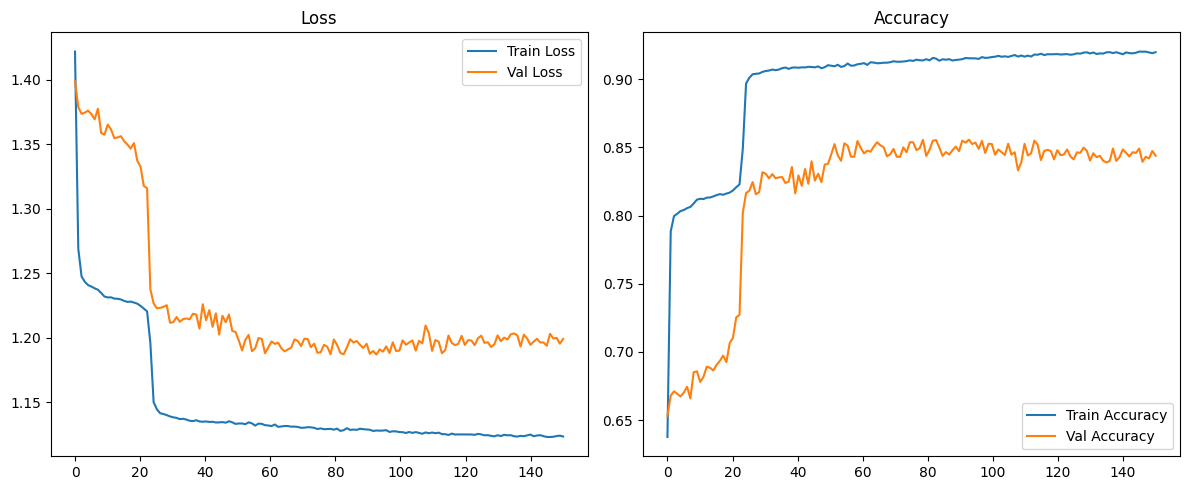

              precision    recall  f1-score   support

           0       0.90      0.93      0.91      7736
           1       0.89      0.92      0.90      6210
           2       0.89      0.91      0.90      5112
           3       0.75      0.88      0.81      2623
           4       0.80      0.86      0.83      1325
           5       0.74      0.63      0.68      7322

    accuracy                           0.84     30328
   macro avg       0.83      0.85      0.84     30328
weighted avg       0.84      0.84      0.84     30328



In [67]:
result1 = eval_net(dataset_name, 'model4')

### Ocean - regNN

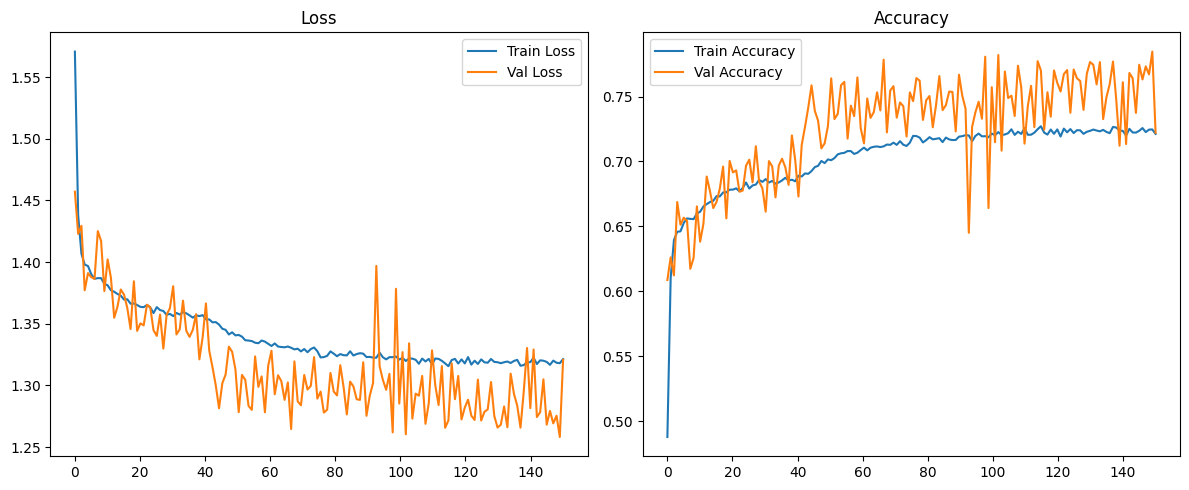

              precision    recall  f1-score   support

           0       0.69      0.97      0.81      7736
           1       0.72      0.82      0.77      6210
           2       0.79      0.82      0.80      5112
           3       0.59      0.63      0.61      2623
           4       0.76      0.79      0.78      1325
           5       0.81      0.33      0.47      7322

    accuracy                           0.72     30328
   macro avg       0.73      0.73      0.71     30328
weighted avg       0.74      0.72      0.70     30328



In [68]:
result2 = eval_net(dataset_name, 'model5')

### Ocean - CNN1

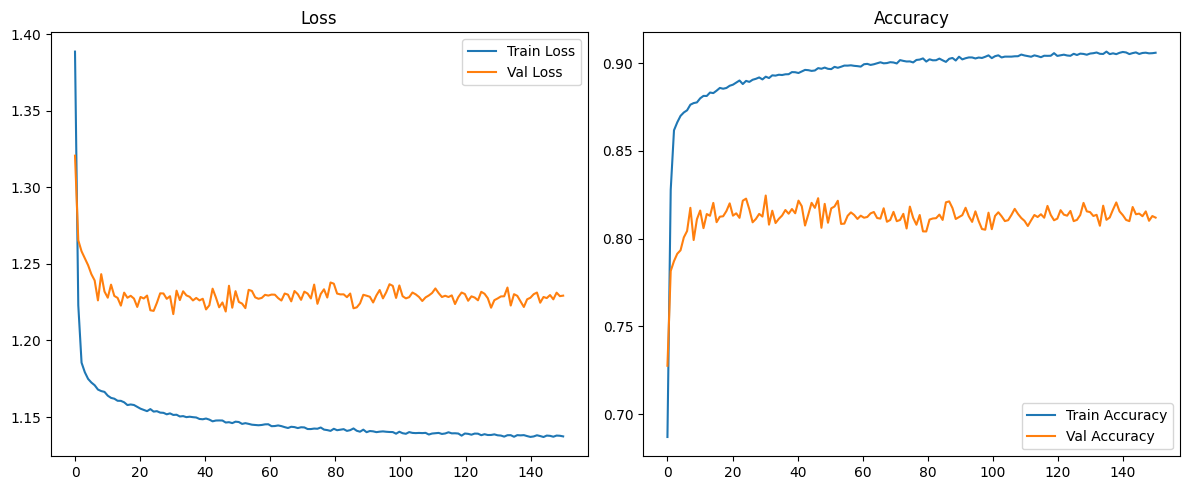

              precision    recall  f1-score   support

           0       0.89      0.90      0.90      7736
           1       0.86      0.87      0.87      6210
           2       0.83      0.94      0.88      5112
           3       0.70      0.74      0.72      2623
           4       0.82      0.71      0.76      1325
           5       0.70      0.62      0.66      7322

    accuracy                           0.81     30328
   macro avg       0.80      0.80      0.80     30328
weighted avg       0.81      0.81      0.81     30328



In [69]:
result3 = eval_net(dataset_name, 'model6')

### Ocean - ROC AUC Confusion Matrix

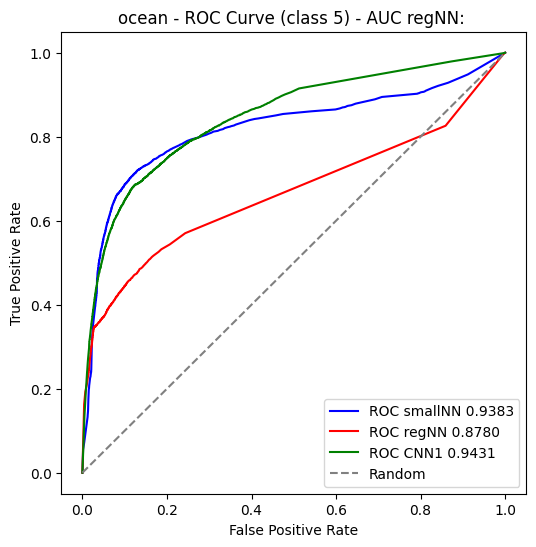

In [78]:
y_val_labels = y_val.detach().numpy().argmax(axis=1)

roc4 = roc_auc_score(y_val_labels, result1['pred_proba'][0], multi_class='ovr')
roc5 = roc_auc_score(y_val_labels, result2['pred_proba'][0], multi_class='ovr')
roc6 = roc_auc_score(y_val_labels, result3['pred_proba'][0], multi_class='ovr')

class_idx = 5 # roc curve for each class

fpr4, tpr4, _ = roc_curve(y_val_labels == class_idx, result1['pred_proba'][0][:, class_idx])
fpr5, tpr5, _ = roc_curve(y_val_labels == class_idx, result2['pred_proba'][0][:, class_idx])
fpr6, tpr6, _ = roc_curve(y_val_labels == class_idx, result3['pred_proba'][0][:, class_idx])

plt.figure(figsize=(6,6))
plt.title(f'{dataset_name} - ROC Curve (class {class_idx}) - AUC regNN: ')
plt.plot(fpr4, tpr4, color='blue', label=f'ROC smallNN {roc4:.4f}')
plt.plot(fpr5, tpr5, color='red', label=f'ROC regNN {roc5:.4f}')
plt.plot(fpr6, tpr6, color='green', label=f'ROC CNN1 {roc6:.4f}')
plt.plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

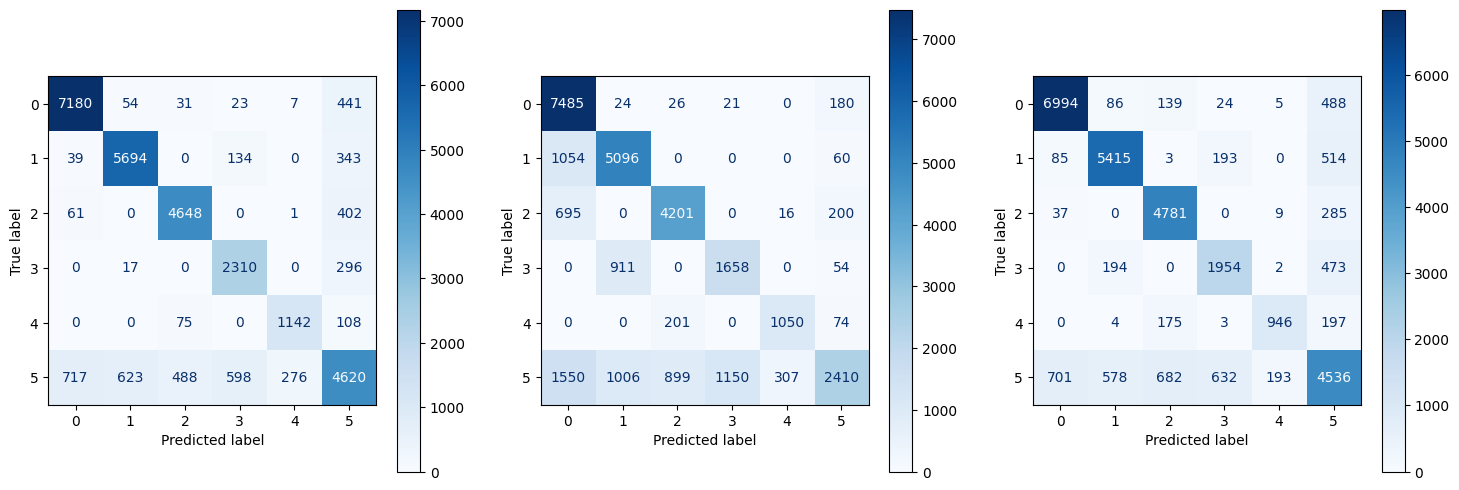

In [71]:
plot_conf_matrix(y_val, result1, result2, result3)

## **WINE**

In [47]:
dataset_name = "wine"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(3918, 9) (780, 9) (200, 9)


### Wine - smallNN

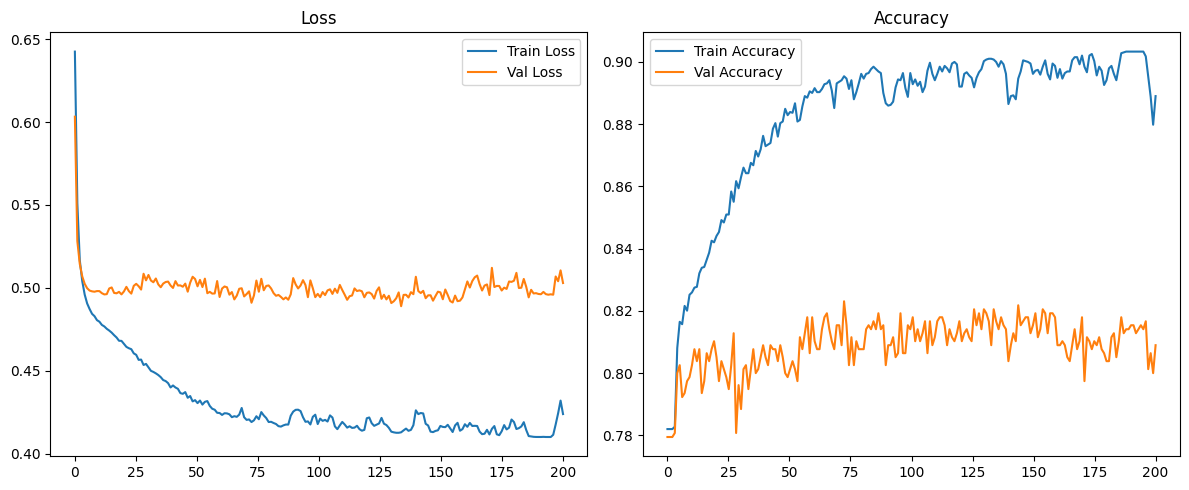

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       608
           1       0.59      0.45      0.51       172

    accuracy                           0.81       780
   macro avg       0.72      0.68      0.70       780
weighted avg       0.80      0.81      0.80       780



In [48]:
result1 = eval_net(dataset_name, 'model4')

### Wine - regNN

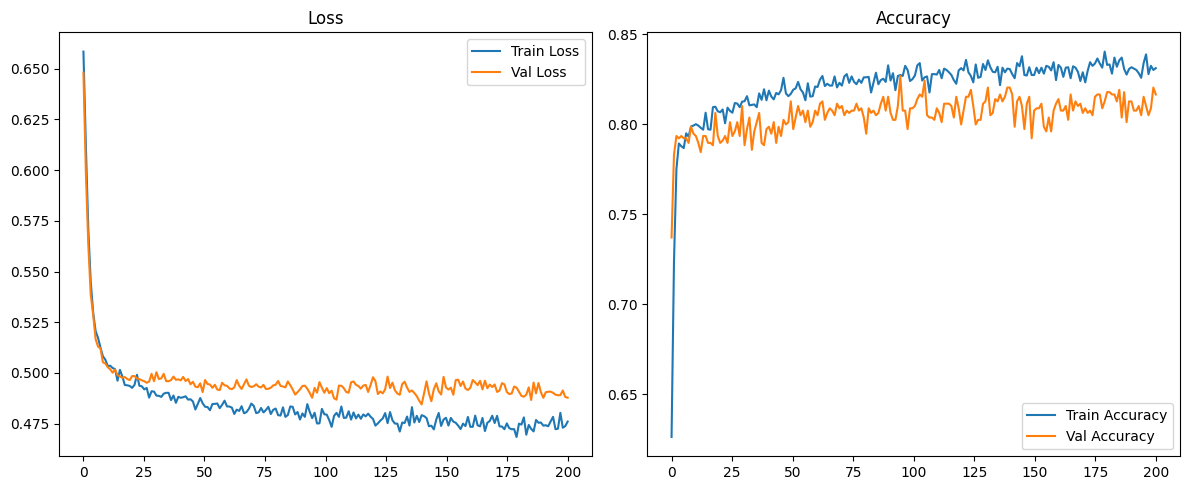

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       608
           1       0.61      0.46      0.52       172

    accuracy                           0.82       780
   macro avg       0.73      0.69      0.71       780
weighted avg       0.80      0.82      0.81       780



In [49]:
result2 = eval_net(dataset_name, 'model5')

### Wine - CNN1

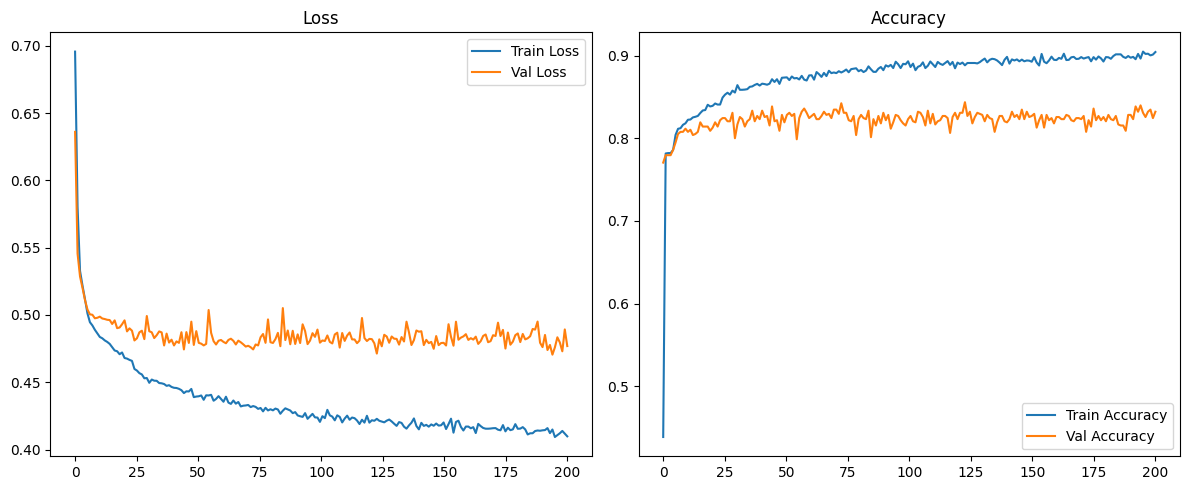

              precision    recall  f1-score   support

           0       0.86      0.94      0.90       608
           1       0.68      0.46      0.55       172

    accuracy                           0.83       780
   macro avg       0.77      0.70      0.72       780
weighted avg       0.82      0.83      0.82       780



In [50]:
result3 = eval_net(dataset_name, 'model6')

### Wine - ROC AUC Confusion Matrix

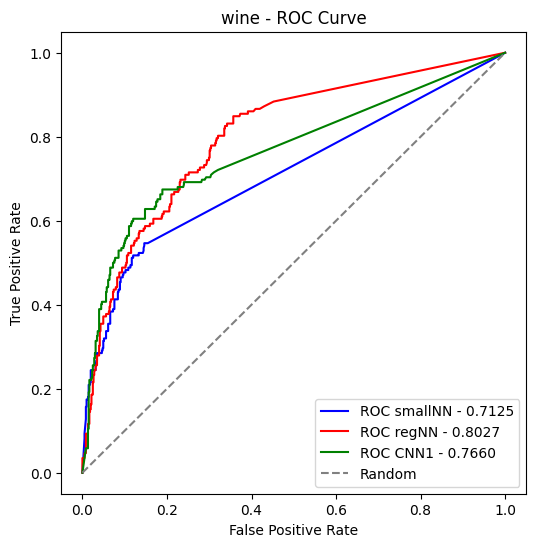

In [51]:
plot_roc(y_val, result1, result2, result3, dataset_name)

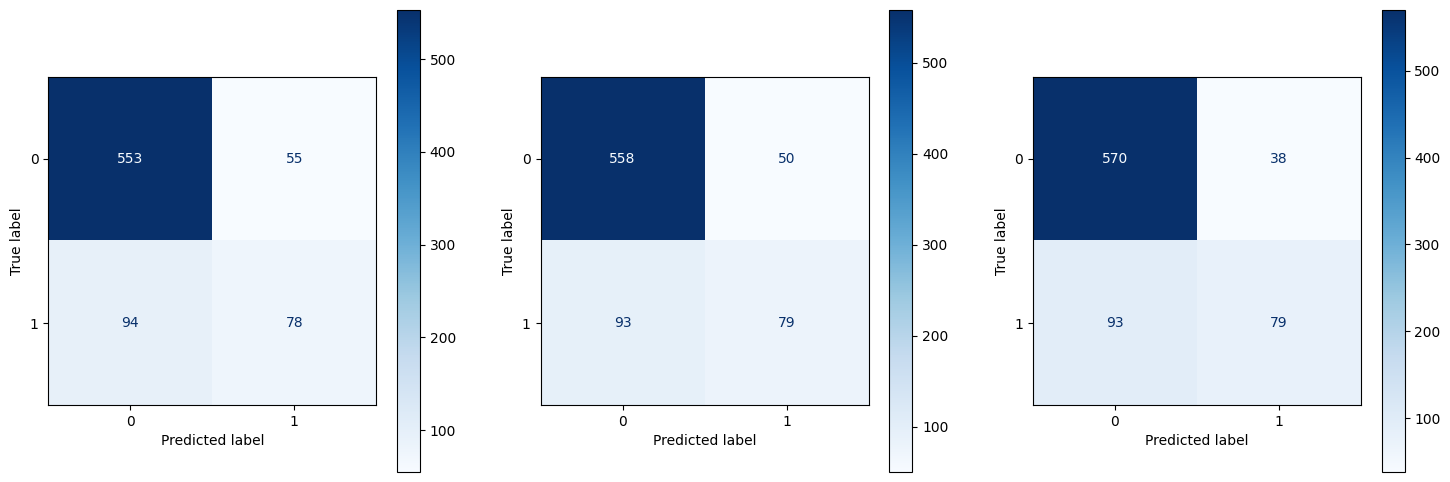

In [52]:
plot_conf_matrix(y_val, result1, result2, result3)

## Conclusioni

In [53]:
model_dict = joblib.load(f"./load/nets/model_{dataset_name}_dict.joblib")
print(model_dict)

{'model1': smallNN(
  (linear1): Linear(in_features=9, out_features=64, bias=True)
  (sigmoid1): ReLU()
  (linear2): Linear(in_features=64, out_features=32, bias=True)
  (sigmoid2): ReLU()
  (linear3): Linear(in_features=32, out_features=16, bias=True)
  (sigmoid3): ReLU()
  (linear4): Linear(in_features=16, out_features=2, bias=True)
  (softmax): Softmax(dim=None)
), 'model2': deeperNN(
  (linear1): Linear(in_features=9, out_features=64, bias=True)
  (sigmoid1): ReLU()
  (linear2): Linear(in_features=64, out_features=32, bias=True)
  (sigmoid2): ReLU()
  (linear3): Linear(in_features=32, out_features=16, bias=True)
  (sigmoid3): ReLU()
  (linear4): Linear(in_features=16, out_features=8, bias=True)
  (sigmoid4): ReLU()
  (linear5): Linear(in_features=8, out_features=2, bias=True)
  (softmax): Softmax(dim=None)
), 'model3': shallowNN(
  (linear1): Linear(in_features=9, out_features=16, bias=True)
  (sigmoid1): ReLU()
  (linear2): Linear(in_features=16, out_features=16, bias=True)
  (sig